In [2]:
# ==========================================
# SETUP, CONFIGURATION & DIRECTORIES
# ==========================================
import os
import re
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch
from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity

# Disable Windows symlink warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Create organized directory structure
DIRECTORIES = [
    "data/raw",
    "data/chunked/baseline",
    "data/chunked/advanced",
    "data/indices",
    "results/payloads",
    "results/plots"
]
for directory in DIRECTORIES:
    os.makedirs(directory, exist_ok=True)
print("Project directories initialized successfully.")

# Global Configuration
HEADERS = {"User-Agent": "COMP64702_RAG_Project_Team PythonRequests"}

# Shared URL Lists
WIKI_URLS = [
    "https://en.wikipedia.org/wiki/Aloo_gobi", "https://en.wikipedia.org/wiki/Andhra_cuisine",
    "https://en.wikipedia.org/wiki/Anglo-Indian_cuisine", "https://en.wikipedia.org/wiki/Assamese_cuisine",
    "https://en.wikipedia.org/wiki/Awadhi_cuisine", "https://en.wikipedia.org/wiki/Balochi_cuisine",
    "https://en.wikipedia.org/wiki/Bangladeshi_cuisine", "https://en.wikipedia.org/wiki/Bengali_cuisine",
    "https://en.wikipedia.org/wiki/Bhojpuri_cuisine", "https://en.wikipedia.org/wiki/Bihari_cuisine",
    "https://en.wikipedia.org/wiki/Chettinad_cuisine", "https://en.wikipedia.org/wiki/Chutney",
    "https://en.wikipedia.org/wiki/Cuisine_of_Uttar_Pradesh", "https://en.wikipedia.org/wiki/Dal",
    "https://en.wikipedia.org/wiki/Dosa_(food)", "https://en.wikipedia.org/wiki/East_India#Cuisine",
    "https://en.wikipedia.org/wiki/Goan_Catholic_cuisine", "https://en.wikipedia.org/wiki/Goan_cuisine",
    "https://en.wikipedia.org/wiki/Gujarati_cuisine", "https://en.wikipedia.org/wiki/Hazara_cuisine",
    "https://en.wikipedia.org/wiki/Hyderabadi_cuisine", "https://en.wikipedia.org/wiki/Indian_Chinese_cuisine",
    "https://en.wikipedia.org/wiki/Indian_South_Africans#Cuisine", "https://en.wikipedia.org/wiki/Indian_cuisine",
    "https://en.wikipedia.org/wiki/Indian_fast_food", "https://en.wikipedia.org/wiki/Jain_vegetarianism",
    "https://en.wikipedia.org/wiki/Jharkhandi_cuisine", "https://en.wikipedia.org/wiki/Karahi",
    "https://en.wikipedia.org/wiki/Karnataka_cuisine", "https://en.wikipedia.org/wiki/Kashmiri_cuisine",
    "https://en.wikipedia.org/wiki/Kerala_cuisine", "https://en.wikipedia.org/wiki/Kodava_people",
    "https://en.wikipedia.org/wiki/Lahori_cuisine", "https://en.wikipedia.org/wiki/Maharashtrian_cuisine",
    "https://en.wikipedia.org/wiki/Maithil_cuisine", "https://en.wikipedia.org/wiki/Malaysian_Indian_cuisine",
    "https://en.wikipedia.org/wiki/Maldivian_cuisine", "https://en.wikipedia.org/wiki/Malvani_cuisine",
    "https://en.wikipedia.org/wiki/Mangalorean_Catholic_Cuisine", "https://en.wikipedia.org/wiki/Manipuri_cuisine",
    "https://en.wikipedia.org/wiki/Meitei_cuisine", "https://en.wikipedia.org/wiki/Mizo_cuisine",
    "https://en.wikipedia.org/wiki/Mughlai_cuisine", "https://en.wikipedia.org/wiki/Muhajir_cuisine",
    "https://en.wikipedia.org/wiki/Naan", "https://en.wikipedia.org/wiki/Naga_cuisine",
    "https://en.wikipedia.org/wiki/Nepalese_cuisine", "https://en.wikipedia.org/wiki/Newari_cuisine",
    "https://en.wikipedia.org/wiki/North_East_Indian_cuisine", "https://en.wikipedia.org/wiki/North_Indian_cuisine",
    "https://en.wikipedia.org/wiki/North_Karnataka", "https://en.wikipedia.org/wiki/Odia_cuisine",
    "https://en.wikipedia.org/wiki/Oriya_cuisine", "https://en.wikipedia.org/wiki/Pakistani_cuisine",
    "https://en.wikipedia.org/wiki/Parsi_cuisine", "https://en.wikipedia.org/wiki/Pashtun_cuisine",
    "https://en.wikipedia.org/wiki/Punjabi_cuisine", "https://en.wikipedia.org/wiki/Raita",
    "https://en.wikipedia.org/wiki/Rajasthani_cuisine", "https://en.wikipedia.org/wiki/Rice",
    "https://en.wikipedia.org/wiki/Sambar_(dish)", "https://en.wikipedia.org/wiki/Saraiki_cuisine",
    "https://en.wikipedia.org/wiki/Seekh_kebab", "https://en.wikipedia.org/wiki/Shahi_paneer",
    "https://en.wikipedia.org/wiki/Sikkimese_cuisine", "https://en.wikipedia.org/wiki/Sindhi_cuisine",
    "https://en.wikipedia.org/wiki/South_Asian_cuisine", "https://en.wikipedia.org/wiki/South_Indian_cuisine",
    "https://en.wikipedia.org/wiki/South_Karnataka", "https://en.wikipedia.org/wiki/Sri_Lankan_cuisine",
    "https://en.wikipedia.org/wiki/Tamil_cuisine", "https://en.wikipedia.org/wiki/Telugu_cuisine",
    "https://en.wikipedia.org/wiki/Thali", "https://en.wikipedia.org/wiki/Tripuri_cuisine",
    "https://en.wikipedia.org/wiki/Udupi_cuisine"
]

WIKIBOOKS_URLS = [
    "https://en.wikibooks.org/wiki/Cookbook:Afghan_Bread", "https://en.wikibooks.org/wiki/Cookbook:Chicken_Tikka",
    "https://en.wikibooks.org/wiki/Cookbook:Naan", "https://en.wikibooks.org/wiki/Cookbook:Arisa_Pitha_(Fried_Indian_Sweet_Rice_Pastry)",
    "https://en.wikibooks.org/wiki/Cookbook:Chyapa_Shutki_Bharta", "https://en.wikibooks.org/wiki/Cookbook:Bhuna_Khichuri_(Bengali_Rice_and_Lentils)",
    "https://en.wikibooks.org/wiki/Cookbook:Mishti_Doi_(Bengali_Sweetened_Yogurt)", "https://en.wikibooks.org/wiki/Cookbook:Murghi_Korma_(Chicken_Korma)",
    "https://en.wikibooks.org/wiki/Cookbook:Pudina_Hilsa_(Bengali_Fish_with_Mint)", "https://en.wikibooks.org/wiki/Cookbook:Rosogulla_(Bengali_Milk_Balls_in_Syrup)",
    "https://en.wikibooks.org/wiki/Cookbook:Fried_Wheat_Bread_Balls_(Bhatoora)", "https://en.wikibooks.org/wiki/Cookbook:Makki_di_Roti_(Indian_Cornmeal_Flatbread)",
    "https://en.wikibooks.org/wiki/Cookbook:Potato_and_Cauliflower_Curry_(Aloo_Gobi)", "https://en.wikibooks.org/wiki/Cookbook:Salty_(Namkin)_Lassi",
    "https://en.wikibooks.org/wiki/Cookbook:Tandoori_Masala", "https://en.wikibooks.org/wiki/Cookbook:Appam_(Fermented_Rice_Pancake)",
    "https://en.wikibooks.org/wiki/Cookbook:Bonda_(South_Indian_Vegetable_Fritter)", "https://en.wikibooks.org/wiki/Cookbook:Hyderabad_Biryani",
    "https://en.wikibooks.org/wiki/Cookbook:Hyderabadi_Fried_Bread_with_Syrup_and_Nuts_(Double_ka_meetha)", "https://en.wikibooks.org/wiki/Cookbook:Idiyappam_(South_Indian_Rice_Noodles)",
    "https://en.wikibooks.org/wiki/Cookbook:Idli_(Steamed_Rice_and_Black_Gram_Bread)", "https://en.wikibooks.org/wiki/Cookbook:Kesari_(South_Indian_Semolina_Pudding)",
    "https://en.wikibooks.org/wiki/Cookbook:Khara_Pongal_(Rice_and_Mung_Bean_Porridge)", "https://en.wikibooks.org/wiki/Cookbook:Ragi_Dosa_(South_Indian_Millet_and_Rice_Pancake)",
    "https://en.wikibooks.org/wiki/Cookbook:Tamate_Ka_Kut_(Hyderabadi_Tomato_Curry)", "https://en.wikibooks.org/wiki/Cookbook:Chukauni_(Nepalese_Potato_Salad)",
    "https://en.wikibooks.org/wiki/Cookbook:Jhilinga_(Nepalese_Rice_Fritters)", "https://en.wikibooks.org/wiki/Cookbook:Masyaura_(Nepali_Fermented_Vegetable_Balls)",
    "https://en.wikibooks.org/wiki/Cookbook:Tibetan_Meat_Momos", "https://en.wikibooks.org/wiki/Cookbook:Aloo_Tikki_(Spiced_Potato_Patties)",
    "https://en.wikibooks.org/wiki/Cookbook:Basin_Ki_Kadi_(Sindhi_Chickpea_Flour_Curry)", "https://en.wikibooks.org/wiki/Cookbook:Chola_and_Roti",
    "https://en.wikibooks.org/wiki/Cookbook:Gobi_Bhagi_(Spiced_Cauliflower_Stew)", "https://en.wikibooks.org/wiki/Cookbook:Mustard_and_Curry_Leaf_Lassi",
    "https://en.wikibooks.org/wiki/Cookbook:Plain_Lassi", "https://en.wikibooks.org/wiki/Cookbook:Rajma_(Sindhi_Kidney_Bean_Curry)",
    "https://en.wikibooks.org/wiki/Cookbook:Sai_Bhaji_(Sindhi_Vegetable_Curry)", "https://en.wikibooks.org/wiki/Cookbook:Seviyan_Ji_Khirni_(Sindhi_Vermicelli_Pudding)",
    "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Chickpea_Confection", "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Fried_Potatoes",
    "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Pulao", "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Raitha",
    "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Spiced_Fish", "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Spiced_Moong_Dal",
    "https://en.wikibooks.org/wiki/Cookbook:Sindhi_Vegetable_Kofta", "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Beef_Curry",
    "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Biryani", "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Doner_Kebab",
    "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Fried_Rice", "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Handesh",
    "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Onion_and_Rice_Fritters", "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Rice_Pudding",
    "https://en.wikibooks.org/wiki/Cookbook:Sylheti_Tangy_Curry", "https://en.wikibooks.org/wiki/Cookbook:Butter_Tea",
    "https://en.wikibooks.org/wiki/Cookbook:Corom_Chatni_(Mango_Chutney_with_Hot_Chillies)", "https://en.wikibooks.org/wiki/Cookbook:Dum_ka_Qimah_(Spiced_Minced_Meat)",
    "https://en.wikibooks.org/wiki/Cookbook:Khatti_Dal_(Spiced_Tamarind_Pigeon_Peas)", "https://en.wikibooks.org/wiki/Cookbook:Malpua_(South_Asian_Sweet_Pancake)",
    "https://en.wikibooks.org/wiki/Cookbook:Mango_Chutney_(Chunky)", "https://en.wikibooks.org/wiki/Cookbook:Mango_Chutney_(Smooth)",
    "https://en.wikibooks.org/wiki/Cookbook:Masala_Chai_II", "https://en.wikibooks.org/wiki/Cookbook:Mild_Salty_Lassi",
    "https://en.wikibooks.org/wiki/Cookbook:Papadam_(Black_Gram_Flatbread)", "https://en.wikibooks.org/wiki/Cookbook:Papaya_Lassi",
    "https://en.wikibooks.org/wiki/Cookbook:Papri_Chaat_(Crispy_Indian_Snack_with_Potato)", "https://en.wikibooks.org/wiki/Cookbook:Phulourie_(Split_Pea_Fritters)",
    "https://en.wikibooks.org/wiki/Cookbook:Prawn_Curry", "https://en.wikibooks.org/wiki/Cookbook:Qabuli_(Central_Asian_Rice_Pilaf)",
    "https://en.wikibooks.org/wiki/Cookbook:Sweet_Lassi", "https://en.wikibooks.org/wiki/Cookbook:Sweet_Mango_Lassi",
    "https://en.wikibooks.org/wiki/Cookbook:Watalappam_(Sri_Lankan_Coconut_Custard)"
]

BLOG_URLS = [
    "https://aroundtheworldin80cuisinesblog.wordpress.com/category/06-northern-india/",
    "https://aroundtheworldin80cuisinesblog.wordpress.com/category/38-afghanistan/",
    "https://aroundtheworldin80cuisinesblog.wordpress.com/category/44-southern-india/",
    "https://aroundtheworldin80cuisinesblog.wordpress.com/category/54-pakistan/",
    "https://aroundtheworldin80cuisinesblog.wordpress.com/category/20-sri-lanka-and-the-maldives/"
]

Project directories initialized successfully.


In [3]:
# ==========================================
# RAW DATA INGESTION
# Scraping without chunking to save the raw corpus
# ==========================================

# Helper functions for Wikipedia cleaning
def clean_wiki_text(text):
    cleaned = re.sub(r'\[[0-9a-zA-Z]+\]', '', text).replace('[edit]', '')
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return re.sub(r'\[\d+(,\s*\d+)*\]', '', cleaned).strip()

def is_valid_element(element):
    invalid_classes = ['infobox', 'navbox', 'toc', 'reflist', 'reference', 'metadata', 'sidebar', 'mw-empty-elt', 'catlinks', 'printfooter']
    for parent in [element] + list(element.parents):
        classes = parent.get('class')
        if classes and any(c in invalid_classes for c in (classes if isinstance(classes, list) else [classes])): return False
    return True

def wiki_table_to_markdown(table_tag):
    rows = table_tag.find_all('tr')
    md_lines, header_written, has_real_content = [], False, False
    for row in rows:
        cells = row.find_all(['th', 'td'], recursive=False)
        if not cells: continue
        row_data = [clean_wiki_text(c.get_text(separator=" ")).replace('\n', ' ') for c in cells]
        if not any(cell.strip() for cell in row_data): continue
        has_real_content = True
        md_lines.append("| " + " | ".join(row_data) + " |")
        if row.find('th') and not header_written:
            md_lines.append("|" + "|".join(["---"] * len(row_data)) + "|")
            header_written = True
    if not has_real_content: return ""
    if md_lines and not header_written:
        md_lines.insert(1, "|" + "|".join(["---"] * (len(md_lines[0].split('|')) - 2)) + "|")
    return "\n".join(md_lines)

def wiki_list_to_markdown(list_tag, level=0):
    items = []
    for li in list_tag.find_all('li', recursive=False):
        text_parts = [child.get_text(separator=" ") if child.name else child.string for child in li.children if child.name not in ['ul', 'ol'] and child]
        li_text = clean_wiki_text(" ".join(filter(None, text_parts)))
        if li_text: items.append(f"{'  ' * level}- {li_text}")
        for nested_list in li.find_all(['ul', 'ol'], recursive=False):
            items.append(wiki_list_to_markdown(nested_list, level + 1))
    return "\n".join(items)

def scrape_wikipedia_raw(urls):
    raw_data = []
    session = requests.Session()
    session.headers.update(HEADERS)
    skip_sections = ["see also", "references", "further reading", "external links", "bibliography", "notes"]

    for url in tqdm(urls, desc="Scraping Wikipedia", unit="page"):
        try:
            response = session.get(url, timeout=15)
            response.raise_for_status()
        except Exception:
            continue
            
        soup = BeautifulSoup(response.content, 'html.parser')
        for tag in soup.find_all(['sup', 'span', 'div', 'table', 'ul', 'figure', 'figcaption'], class_=re.compile(r'(reference|mw-editsection|noprint|thumb|gallery)')):
            tag.decompose()
            
        title_tag = soup.find('h1', id='firstHeading')
        topic = title_tag.get_text(strip=True) if title_tag else "Unknown Topic"
        content_div = soup.find('div', class_='mw-parser-output')
        if not content_div: continue

        current_section = "Summary"
        skip_current_section = False

        for element in content_div.find_all(['h2', 'h3', 'h4', 'h5', 'p', 'ul', 'ol', 'table']):
            if not is_valid_element(element): continue
            if element.name in ['h2', 'h3', 'h4', 'h5']:
                current_section = clean_wiki_text(element.get_text(separator=" "))
                skip_current_section = any(skip in current_section.lower() for skip in skip_sections)
                continue
            if skip_current_section or any(parent.name in ['table', 'ul', 'ol'] for parent in element.parents): continue
                
            base_metadata = {"source": "Wikipedia", "topic": topic, "section": current_section, "url": url}

            if element.name == 'p':
                text = clean_wiki_text(element.get_text(separator=" "))
                if len(text) > 15 and re.search(r'[a-zA-Z0-9]', text):
                    raw_data.append({"text": text, "metadata": base_metadata, "is_table": False})
            elif element.name in ['ul', 'ol']:
                md_list = wiki_list_to_markdown(element)
                if len(md_list) > 10 and re.search(r'[a-zA-Z0-9]', md_list):
                    raw_data.append({"text": md_list, "metadata": base_metadata, "is_table": False})
            elif element.name == 'table':
                md_table = wiki_table_to_markdown(element)
                if md_table and re.search(r'[a-zA-Z0-9]', md_table):
                    raw_data.append({"text": md_table, "metadata": base_metadata, "is_table": True})
        time.sleep(1)
    return raw_data

def scrape_wikibooks_raw(urls):
    raw_data = []
    for url in tqdm(urls, desc="Scraping Wikibooks", unit="page"):
        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, "html.parser") 
            title_element = soup.find("h1", id="firstHeading")
            recipe_name = title_element.text.replace("Cookbook:", "").strip() if title_element else "Unknown"
            content_area = soup.find(id="mw-content-text")
            
            if content_area:
                elements = content_area.find_all(['h2', 'h3', 'p', 'ul', 'ol', 'table'])
                current_section = "Introduction"
                for element in elements:
                    if element.name in ['h2', 'h3']:
                        current_section = element.get_text().replace('[edit]', '').strip()
                    elif element.name == 'p':
                        text = element.get_text().strip()
                        if "Cookbook |" in text or "Recipes |" in text: continue 
                        if len(text) > 15:
                            clean_text = re.sub(r'\[\w+\]', '', text)
                            meta = {"source": "Wikibooks", "topic": recipe_name, "section": current_section, "url": url}
                            raw_data.append({"text": clean_text, "metadata": meta, "is_table": False})
                    elif element.name in ['ul', 'ol']:
                        if element.parent.has_attr('class') and 'navbox' in element.parent['class']: continue
                        list_items = element.find_all('li')
                        if list_items:
                            combined_list_text = "\n".join([f"- {li.get_text().strip()}" for li in list_items if li.get_text().strip()])
                            if len(combined_list_text) > 10:
                                clean_text = re.sub(r'\[\w+\]', '', combined_list_text)
                                meta = {"source": "Wikibooks", "topic": recipe_name, "section": current_section, "url": url}
                                raw_data.append({"text": clean_text, "metadata": meta, "is_table": False})
                    elif element.name == 'table':
                        if element.has_attr('class') and any(c in ['navbox', 'toc', 'infobox'] for c in element['class']): continue
                        table_rows = []
                        for row in element.find_all('tr'):
                            cells = [cell.get_text(strip=True) for cell in row.find_all(['th', 'td'])]
                            if any(cells): table_rows.append(" | ".join(cells))
                        if table_rows:
                            combined_table_text = "Table Data:\n" + "\n".join(table_rows)
                            clean_text = re.sub(r'\[\w+\]', '', combined_table_text)
                            meta = {"source": "Wikibooks", "topic": recipe_name, "section": current_section, "url": url}
                            raw_data.append({"text": clean_text, "metadata": meta, "is_table": True})
        time.sleep(1)
    return raw_data

def scrape_blog_raw(urls):
    raw_data = []
    for url in tqdm(urls, desc="Scraping Blog", unit="page"):
        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, "html.parser")
            title_element = soup.find("h1", class_="entry-title") or soup.find("h1")
            post_title = title_element.get_text().strip() if title_element else "Unknown"
            content_area = soup.find("div", class_="entry-content")
            if content_area:
                elements = content_area.find_all(['h2', 'h3', 'p', 'ul'])
                current_section = "Blog Narrative"
                for element in elements:
                    if element.name in ['h2', 'h3']:
                        current_section = element.get_text().strip()
                    elif element.name == 'p':
                        text = element.get_text().strip()
                        if "Share this:" in text or "Like this:" in text or len(text) < 15: continue
                        clean_text = re.sub(r'\[\w+\]', '', text).strip()
                        if clean_text:
                            meta = {"source": "Around the World in 80 Cuisines", "topic": post_title, "section": current_section, "url": url}
                            raw_data.append({"text": clean_text, "metadata": meta, "is_table": False})
                    elif element.name == 'ul':
                        list_items = [li.get_text().strip() for li in element.find_all('li') if "Share" not in li.get_text() and li.get_text().strip()]
                        if list_items:
                            combined_list_text = "\n".join([f"- {item}" for item in list_items])
                            if len(combined_list_text) > 10:
                                meta = {"source": "Around the World in 80 Cuisines", "topic": post_title, "section": current_section, "url": url}
                                raw_data.append({"text": combined_list_text, "metadata": meta, "is_table": False})
        time.sleep(1)
    return raw_data

print("Starting Data Ingestion...")
wiki_raw = scrape_wikipedia_raw(WIKI_URLS)
wikibooks_raw = scrape_wikibooks_raw(WIKIBOOKS_URLS)
blog_raw = scrape_blog_raw(BLOG_URLS)

with open("data/raw/wikipedia_raw.json", "w", encoding="utf-8") as f: json.dump(wiki_raw, f, indent=4)
with open("data/raw/wikibooks_raw.json", "w", encoding="utf-8") as f: json.dump(wikibooks_raw, f, indent=4)
with open("data/raw/blog_raw.json", "w", encoding="utf-8") as f: json.dump(blog_raw, f, indent=4)
print("Raw ingestion complete. Files saved in data/raw/")

Starting Data Ingestion...


Scraping Wikipedia:   0%|          | 0/75 [00:00<?, ?page/s]

Scraping Wikibooks:   0%|          | 0/71 [00:00<?, ?page/s]

Scraping Blog:   0%|          | 0/5 [00:00<?, ?page/s]

Raw ingestion complete. Files saved in data/raw/


In [4]:
# ==========================================
# CHUNKING STRATEGIES
# Reads raw data and outputs chunked data to respective folders
# ==========================================

# Baseline Splitting (Flat 800-char)
baseline_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, chunk_overlap=100, length_function=len, separators=["\n\n", "\n", ". ", " "]
)

def process_baseline_chunks(raw_data):
    chunks = []
    for item in tqdm(raw_data, desc="Processing Baseline Chunks", leave=False):
        clean_text, base_metadata, is_table = item["text"], item["metadata"], item.get("is_table", False)
        if is_table or len(clean_text) <= 800:
            meta = base_metadata.copy()
            meta.update({"chunk_index": 1, "total_chunks": 1})
            chunks.append({"text": clean_text, "metadata": meta})
        else:
            split_texts = baseline_splitter.split_text(clean_text)
            for i, chunk in enumerate(split_texts):
                meta = base_metadata.copy()
                meta.update({"chunk_index": i + 1, "total_chunks": len(split_texts)})
                chunks.append({"text": chunk, "metadata": meta})
    return chunks

# Advanced Splitting (Parent-Child)
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=150)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)

def process_advanced_chunks(raw_data):
    chunks = []
    for item in tqdm(raw_data, desc="Processing Advanced Chunks", leave=False):
        clean_text, base_metadata, is_table = item["text"], item["metadata"], item.get("is_table", False)
        parents = [clean_text] if (is_table or len(clean_text) <= 1500) else parent_splitter.split_text(clean_text)
        for p_idx, parent_text in enumerate(parents):
            children = [parent_text] if (is_table or len(parent_text) <= 300) else child_splitter.split_text(parent_text)
            for c_idx, child_text in enumerate(children):
                meta = base_metadata.copy()
                meta["parent_id"] = f"{base_metadata['topic']}_{base_metadata['section']}_p{p_idx}"
                meta["parent_text"] = parent_text
                meta["chunk_index"] = c_idx + 1
                meta["total_chunks"] = len(children)
                chunks.append({"text": child_text, "metadata": meta})
    return chunks

# Execute Chunking Pipeline
print("Starting Chunking Operations...")
for filename in ["wikipedia_raw.json", "wikibooks_raw.json", "blog_raw.json"]:
    with open(f"data/raw/{filename}", "r", encoding="utf-8") as f:
        raw_data = json.load(f)
        
    base_name = filename.replace("_raw.json", "")
    
    # Generate and save Baseline
    baseline_output = process_baseline_chunks(raw_data)
    with open(f"data/chunked/baseline/{base_name}_baseline.json", "w", encoding="utf-8") as f:
        json.dump(baseline_output, f, indent=4)
        
    # Generate and save Advanced
    advanced_output = process_advanced_chunks(raw_data)
    with open(f"data/chunked/advanced/{base_name}_advanced.json", "w", encoding="utf-8") as f:
        json.dump(advanced_output, f, indent=4)

print("Chunking complete. Files saved in data/chunked/baseline/ and data/chunked/advanced/")

Starting Chunking Operations...


Processing Baseline Chunks:   0%|          | 0/1542 [00:00<?, ?it/s]

Processing Advanced Chunks:   0%|          | 0/1542 [00:00<?, ?it/s]

Processing Baseline Chunks:   0%|          | 0/264 [00:00<?, ?it/s]

Processing Advanced Chunks:   0%|          | 0/264 [00:00<?, ?it/s]

Processing Baseline Chunks:   0%|          | 0/25 [00:00<?, ?it/s]

Processing Advanced Chunks:   0%|          | 0/25 [00:00<?, ?it/s]

Chunking complete. Files saved in data/chunked/baseline/ and data/chunked/advanced/


In [5]:
# ==========================================
# DECOUPLED VECTORIZATION & INDEXING
# Building all 4 combinations of Chunking and Retrieval models
# ==========================================

def build_vector_store(folder_path, index_save_path, metadata_save_path, model_name, index_type="flat"):
    print(f"Loading corpus from {folder_path}...")
    corpus_data = []
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            with open(os.path.join(folder_path, file), 'r', encoding='utf-8') as f:
                corpus_data.extend(json.load(f))

    texts = [item["text"] for item in corpus_data]
    print(f"Initializing Embedding Model: {model_name}")
    model = SentenceTransformer(model_name)

    print(f"Vectorizing texts for {index_save_path}...")
    embeddings = model.encode(texts, show_progress_bar=True)
    embeddings = np.array(embeddings).astype('float32')
    dimension = embeddings.shape[1]
    faiss.normalize_L2(embeddings)

    if index_type == "flat":
        index = faiss.IndexFlatIP(dimension)
    elif index_type == "hnsw":
        index = faiss.IndexHNSWFlat(dimension, 32)
        index.hnsw.efConstruction = 40
        
    index.add(embeddings)

    faiss.write_index(index, index_save_path)
    with open(metadata_save_path, 'w', encoding='utf-8') as f:
        json.dump(corpus_data, f, indent=4, ensure_ascii=False)
    print(f"Saved to {index_save_path}\n")

# 1. Base Chunking + Base Retrieval (MiniLM)
build_vector_store(
    "data/chunked/baseline", 
    "data/indices/baseC_baseR_index.bin", "data/indices/baseC_baseR_meta.json", 
    'sentence-transformers/all-MiniLM-L6-v2', "flat"
)

# 2. Advanced Chunking + Base Retrieval (MiniLM)
build_vector_store(
    "data/chunked/advanced", 
    "data/indices/advC_baseR_index.bin", "data/indices/advC_baseR_meta.json", 
    'sentence-transformers/all-MiniLM-L6-v2', "flat"
)

# 3. Base Chunking + Advanced Retrieval (BGE)
build_vector_store(
    "data/chunked/baseline", 
    "data/indices/baseC_advR_index.bin", "data/indices/baseC_advR_meta.json", 
    'BAAI/bge-small-en-v1.5', "hnsw"
)

# 4. Advanced Chunking + Advanced Retrieval (BGE)
build_vector_store(
    "data/chunked/advanced", 
    "data/indices/advC_advR_index.bin", "data/indices/advC_advR_meta.json", 
    'BAAI/bge-small-en-v1.5', "hnsw"
)

Loading corpus from data/chunked/baseline...
Initializing Embedding Model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizing texts for data/indices/baseC_baseR_index.bin...


Batches:   0%|          | 0/68 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizing texts for data/indices/advC_advR_index.bin...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Saved to data/indices/advC_advR_index.bin



In [6]:
# ==========================================
# PROMPTING & GENERATION STRATEGIES
# Exploring zero-shot vs chain-of-thought prompt engineering
# ==========================================

def get_prompt_messages(query, contexts, strategy="baseline"):
    context_block = "".join([f"--- Source {i+1} ---\n{c['text']}\n\n" for i, c in enumerate(contexts)])
    
    if strategy == "baseline":
        system_instruction = (
            "You are a helpful AI culinary assistant. "
            "Use the provided context to answer the user's question. "
            "If the answer is not in the sources, say you don't know."
        )
        messages = [
            {"role": "system", "content": system_instruction},
            {"role": "user", "content": f"CONTEXT:\n{context_block}\n\nQUESTION: {query}"}
        ]
        
    elif strategy == "advanced":
        system_instruction = (
            "You are an expert South Asian culinary historian and chef. "
            "You must synthesize an accurate answer using ONLY the provided context. "
            "Follow these strict rules:\n"
            "1. Read the context carefully.\n"
            "2. Think step-by-step about how the context addresses the question.\n"
            "3. Provide your final answer concisely. Do not hallucinate ingredients."
        )
        user_prompt = (
            f"Here is the reference material:\n<context>\n{context_block}\n</context>\n\n"
            f"Question: {query}\n\n"
            "Answer format:\n"
            "- Thought Process: [Briefly explain which source helps answer this]\n"
            "- Final Answer: [Your concise answer here]"
        )
        messages = [
            {"role": "system", "content": system_instruction},
            {"role": "user", "content": user_prompt}
        ]
    else:
        raise ValueError("Invalid prompt strategy selected.")
        
    return messages

In [7]:
# ==========================================
# INFERENCE ENGINES
# Defines Baseline and Advanced Retrieval Systems
# ==========================================

class BaselineRAG:
    def __init__(self, index_path, metadata_path, model_name="Qwen/Qwen2.5-0.5B-Instruct"):
        self.embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        self.index = faiss.read_index(index_path)
        with open(metadata_path, 'r', encoding='utf-8') as f:
            self.metadata_store = json.load(f)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto", device_map="auto")

    def retrieve(self, query, final_k=5):
        query_vector = self.embed_model.encode([query])
        faiss.normalize_L2(query_vector)
        distances, indices = self.index.search(np.array(query_vector).astype('float32'), final_k)
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            if idx != -1:
                chunk = self.metadata_store[idx].copy()
                chunk['similarity_score'] = float(dist)
                results.append(chunk)
        return results

    def generate(self, query, retrieved_chunks, strategy="baseline"):
        messages = get_prompt_messages(query, retrieved_chunks, strategy)
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
        generated_ids = self.model.generate(**model_inputs, max_new_tokens=512, temperature=0.1, do_sample=False)
        response_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
        return self.tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0].strip()

class AdvancedRAG:
    def __init__(self, index_path, metadata_path, llm_name="Qwen/Qwen2.5-0.5B-Instruct"):
        self.embed_model = SentenceTransformer('BAAI/bge-small-en-v1.5')
        self.cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
        self.index = faiss.read_index(index_path)
        with open(metadata_path, 'r', encoding='utf-8') as f:
            self.metadata_store = json.load(f)
        self.tokenizer = AutoTokenizer.from_pretrained(llm_name)
        self.model = AutoModelForCausalLM.from_pretrained(llm_name, torch_dtype="auto", device_map="auto")

    def retrieve(self, query, final_k=5):
        query_vector = self.embed_model.encode([query])
        faiss.normalize_L2(query_vector)
        distances, indices = self.index.search(np.array(query_vector).astype('float32'), 20)
        candidates = [self.metadata_store[idx].copy() for idx in indices[0] if idx != -1]

        cross_scores = self.cross_encoder.predict([[query, c['text']] for c in candidates])
        for i, c in enumerate(candidates):
            c['rerank_score'] = float(cross_scores[i])
        candidates = sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)

        final_results = []
        seen_parents = set()
        for chunk in candidates:
            uid = chunk['metadata'].get('parent_id') or chunk['text']
            if uid not in seen_parents:
                seen_parents.add(uid)
                chunk['text'] = chunk['metadata'].get('parent_text', chunk['text'])
                final_results.append(chunk)
            if len(final_results) == final_k: break
        return final_results

    def generate(self, query, retrieved_chunks, strategy="advanced"):
        messages = get_prompt_messages(query, retrieved_chunks, strategy)
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
        generated_ids = self.model.generate(**inputs, max_new_tokens=512, temperature=0.1, do_sample=False)
        response_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, generated_ids)]
        return self.tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0].strip()

In [8]:
# ==========================================
# RIGOROUS ABLATION STUDY
# Isolating variables: Chunking, Retrieval, and Prompting
# ==========================================
import os
import json
from tqdm.auto import tqdm

def run_experiment(pipeline_name, retriever_obj, chunk_strat, ret_strat, prompt_strat, input_json, output_json):
    if not os.path.exists(input_json):
        print(f"Error: {input_json} not found.")
        return

    with open(input_json, 'r', encoding='utf-8') as f:
        queries = json.load(f)["queries"]
        
    results = []
    desc_text = f"{pipeline_name} | C:{chunk_strat[:3]} R:{ret_strat[:3]} P:{prompt_strat[:3]}"
    
    for item in tqdm(queries, desc=desc_text.ljust(40)):
        q_id, query_text = item["query_id"], item["query"]
        
        chunks = retriever_obj.retrieve(query_text, final_k=5)
        answer = retriever_obj.generate(query_text, chunks, strategy=prompt_strat)
        formatted_context = [{"doc_id": str(i).zfill(3), "text": c["text"]} for i, c in enumerate(chunks)]
        
        results.append({
            "query_id": q_id, "query": query_text, "response": answer, "retrieved_context": formatted_context,
            "config": {"chunking": chunk_strat, "retrieval": ret_strat, "prompting": prompt_strat}
        })
        
    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump({"results": results}, f, indent=4, ensure_ascii=False)

print("Loading 4 Decoupled RAG Systems...")
# System 1: Base C + Base R
rag_baseC_baseR = BaselineRAG("data/indices/baseC_baseR_index.bin", "data/indices/baseC_baseR_meta.json")
# System 2: Adv C + Base R
rag_advC_baseR = BaselineRAG("data/indices/advC_baseR_index.bin", "data/indices/advC_baseR_meta.json")
# System 3: Base C + Adv R
rag_baseC_advR = AdvancedRAG("data/indices/baseC_advR_index.bin", "data/indices/baseC_advR_meta.json")
# System 4: Adv C + Adv R
rag_advC_advR = AdvancedRAG("data/indices/advC_advR_index.bin", "data/indices/advC_advR_meta.json")


print("\nExecuting Ablation Study Pipelines...")
# 1. Pure Baseline
run_experiment("P1: Baseline", rag_baseC_baseR, "baseline", "baseline", "baseline", "input_payload.json", "results/payloads/p1_base.json")

# 2. Isolate Chunking Upgrade
run_experiment("P2: Adv Chunk Only", rag_advC_baseR, "advanced", "baseline", "baseline", "input_payload.json", "results/payloads/p2_adv_chunk.json")

# 3. Isolate Retrieval Upgrade
run_experiment("P3: Adv Retr Only", rag_baseC_advR, "baseline", "advanced", "baseline", "input_payload.json", "results/payloads/p3_adv_retr.json")

# 4. Isolate Prompt Upgrade
run_experiment("P4: Adv Prompt Only", rag_baseC_baseR, "baseline", "baseline", "advanced", "input_payload.json", "results/payloads/p4_adv_prompt.json")

# 5. Advanced Vector Database (Chunk + Retr)
run_experiment("P5: Adv DB (C+R)", rag_advC_advR, "advanced", "advanced", "baseline", "input_payload.json", "results/payloads/p5_adv_db.json")

# 6. Ultimate RAG (All Advanced)
run_experiment("P6: Ultimate RAG", rag_advC_advR, "advanced", "advanced", "advanced", "input_payload.json", "results/payloads/p6_ultimate.json")

Loading 4 Decoupled RAG Systems...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

P2: Adv Chunk Only | C:adv R:bas P:bas  :   0%|          | 0/10 [00:00<?, ?it/s]

P3: Adv Retr Only | C:bas R:adv P:bas   :   0%|          | 0/10 [00:00<?, ?it/s]

P4: Adv Prompt Only | C:bas R:bas P:adv :   0%|          | 0/10 [00:00<?, ?it/s]

P5: Adv DB (C+R) | C:adv R:adv P:bas    :   0%|          | 0/10 [00:00<?, ?it/s]

P6: Ultimate RAG | C:adv R:adv P:adv    :   0%|          | 0/10 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


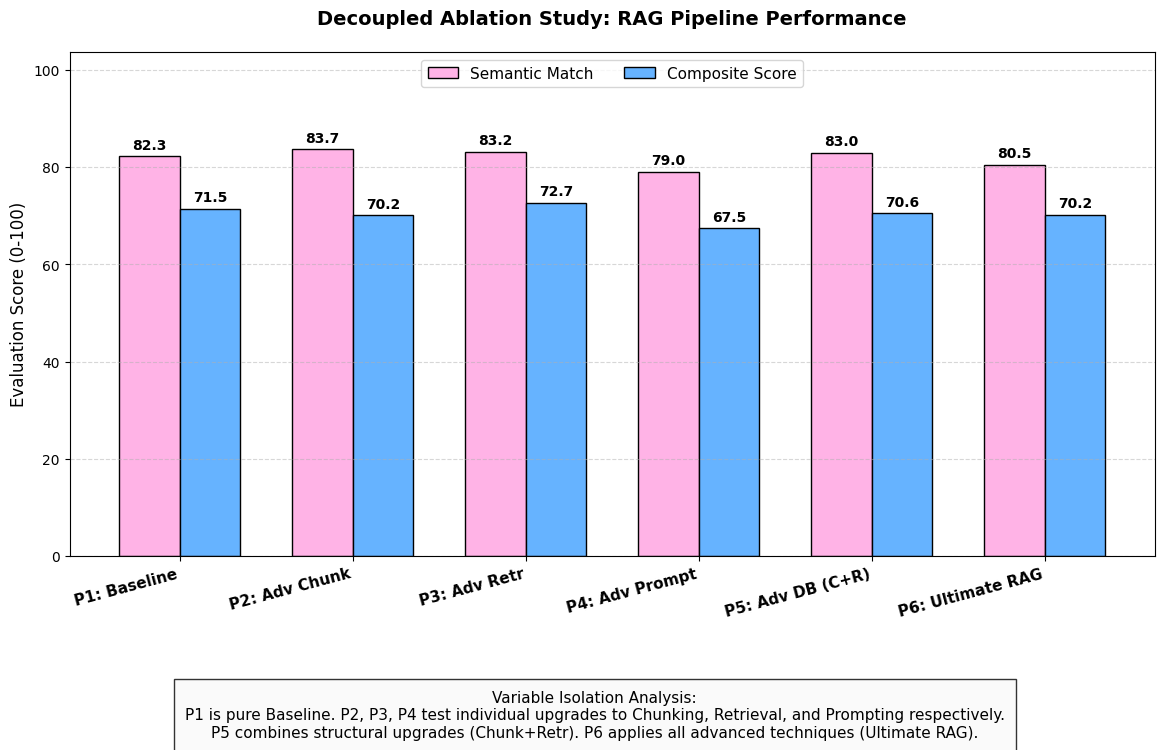

Evaluation complete. Chart saved to results/plots/decoupled_comparison_chart.png


In [ ]:
# ==========================================
# COMPREHENSIVE EVALUATION
# Analyzes results across 6 decoupled pipelines
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

def calculate_lexical_overlap(ground_truth, generated_answer):
    def clean_words(text):
        return set(re.findall(r'\b\w+\b', str(text).lower()))
    gt_words = clean_words(ground_truth)
    gen_words = clean_words(generated_answer)
    if not gt_words: return 0.0
    return (len(gt_words.intersection(gen_words)) / len(gt_words)) * 100

def comprehensive_eval(benchmark_excel, payloads):
    eval_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    df = pd.read_excel(benchmark_excel).head(10)
    
    gt_col = next((col for col in df.columns if any(k in col.lower() for k in ['answer', 'truth', 'response', 'target'])), df.columns[-1])
    qid_col = 'query_id' if 'query_id' in df.columns else df.columns[0]
    
    results_summary = {}
    
    for name, filepath in payloads.items():
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = {item["query_id"]: item["response"] for item in json.load(f)["results"]}
        except FileNotFoundError:
            continue
            
        semantic_scores, lexical_scores = [], []
        
        for index, row in df.iterrows():
            q_id = row[qid_col]
            gt_text = str(row[gt_col])
            gen_text = data.get(q_id, "")
            
            embs = eval_model.encode([gt_text, gen_text])
            sem_score = max(0, cosine_similarity(embs[0].reshape(1,-1), embs[1].reshape(1,-1))[0][0]) * 100
            lex_score = calculate_lexical_overlap(gt_text, gen_text)
            
            semantic_scores.append(sem_score)
            lexical_scores.append(lex_score)
            
        avg_sem = np.mean(semantic_scores)
        avg_lex = np.mean(lexical_scores)
        composite = (avg_sem * 0.6) + (avg_lex * 0.4)
        
        results_summary[name] = {"Semantic": avg_sem, "Composite": composite}
        
    if not results_summary:
        print("No evaluation data found.")
        return
        
    labels = list(results_summary.keys())
    composite_scores = [results_summary[name]["Composite"] for name in labels]
    sem_scores = [results_summary[name]["Semantic"] for name in labels]
    
    x = np.arange(len(labels))
    width = 0.35

    # Increased figure width to accommodate 6 bars comfortably
    fig, ax = plt.subplots(figsize=(14, 8))
    rects1 = ax.bar(x - width/2, sem_scores, width, label='Semantic Match', color='#ffb3e6', edgecolor='black')
    rects2 = ax.bar(x + width/2, composite_scores, width, label='Composite Score', color='#66b3ff', edgecolor='black')

    ax.set_ylabel('Evaluation Score (0-100)', fontsize=12)
    ax.set_title('Decoupled Ablation Study: RAG Pipeline Performance', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=11, fontweight='bold')
    
    max_score = max(max(sem_scores), max(composite_scores))
    ax.set_ylim(0, max_score + 20)

    ax.legend(loc='upper center', ncol=2, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for bars in [rects1, rects2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.subplots_adjust(bottom=0.25)
    
    description = (
        "Variable Isolation Analysis:\n"
        "P1 is pure Baseline. P2, P3, P4 test individual upgrades to Chunking, Retrieval, and Prompting respectively.\n"
        "P5 combines structural upgrades (Chunk+Retr). P6 applies all advanced techniques (Ultimate RAG)."
    )
    plt.figtext(0.5, 0.02, description, ha="center", va="bottom", fontsize=11, 
                bbox={"facecolor":"#f9f9f9", "edgecolor": "black", "alpha":0.8, "pad":8})

    chart_path = "results/plots/decoupled_comparison_chart.png"
    plt.savefig(chart_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Evaluation complete. Chart saved to {chart_path}")
    return results_summary

payloads_to_test = {
    "P1: Baseline": "results/payloads/p1_base.json",
    "P2: Adv Chunk": "results/payloads/p2_adv_chunk.json",
    "P3: Adv Retr": "results/payloads/p3_adv_retr.json",
    "P4: Adv Prompt": "results/payloads/p4_adv_prompt.json",
    "P5: Adv DB (C+R)": "results/payloads/p5_adv_db.json",
    "P6: Ultimate RAG": "results/payloads/p6_ultimate.json"
}

eval_stats = comprehensive_eval("Benchmark Dataset.xlsx", payloads_to_test)

In [ ]:
# ==========================================
# LIVE DEMONSTRATION (CLI)
# Fast, interactive pipeline using the winning P5 model
# ==========================================

print("Loading the winning model (P5: Advanced Retrieval + Baseline Prompt) for Live Demo...")
# This loads in seconds because the scraping and indexing are already done
try:
    demo_rag = AdvancedRAG("data/indices/advC_advR_index.bin", "data/indices/advC_advR_meta.json")
    print("\nSystem ready! Entering interactive mode.")
except Exception as e:
    print(f"Error loading system: {e}. Please ensure Cell 4 has been run previously.")

print("\n" + "="*50)
print("WELCOME TO THE SOUTH ASIAN CULINARY AI CHEF")
print("="*50)
print("Type 'quit' or 'exit' to stop the demonstration.\n")

while True:
    try:
        user_input = input("You: ")
        if user_input.lower() in ['quit', 'exit']:
            print("Goodbye! Ending demonstration.")
            break
        if not user_input.strip():
            continue
            
        print("Thinking...")
        # Retrieval (Fast FAISS search)
        chunks = demo_rag.retrieve(user_input, final_k=5)
        
        # Generation (Using 'baseline' prompt as it performed best in P5)
        answer = demo_rag.generate(user_input, chunks, strategy="baseline")
        
        print(f"\nAI Chef:\n{answer}\n")
        print("-" * 50)
        
    except KeyboardInterrupt:
        print("\nDemonstration interrupted.")
        break

Loading the winning model (P5: Advanced Retrieval + Baseline Prompt) for Live Demo...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


System ready! Entering interactive mode.

WELCOME TO THE SOUTH ASIAN CULINARY AI CHEF
Type 'quit' or 'exit' to stop the demonstration.

Thinking...

AI Chef:
The dum cooking method used in Hyderabadi cuisine is folded the banana leaf towards you (i.e., inwards) to signify that the meal was good. This technique is common when folding the opposite direction (i.e., upwards/away from you) signifies that the meal was not satisfactory.

--------------------------------------------------
Thinking...

AI Chef:
Based on the information provided in the sources, the main vegetables used in Aloo Gobi are:

1. Potatoes (aloo)
2. Cauliflower (gobhi)

These two vegetables are mentioned as the primary ingredients in the dish.

--------------------------------------------------
Thinking...

AI Chef:
Vegetarianism is widely practiced in Indian cuisine because it reflects the diverse ethnic backgrounds of the Indian population. This includes the influence of Jainism, which emphasizes spiritual motivatio

In [ ]:
# ==========================================
# LIVE DEMONSTRATION (GUI - GRADIO)
# Run this cell to launch a web interface inside the notebook
# ==========================================
import gradio as gr

# Ensure demo_rag is loaded from Cell 9
if 'demo_rag' not in locals():
    demo_rag = AdvancedRAG("data/indices/advC_advR_index.bin", "data/indices/advC_advR_meta.json")

def chat_with_bot(message, history):
    # 1. Retrieve context
    chunks = demo_rag.retrieve(message, final_k=5)
    
    # 2. Generate answer using the winning P5 configuration
    answer = demo_rag.generate(message, chunks, strategy="baseline")
    
    # 3. Append retrieved sources to prove the RAG is working correctly
    sources = "\n\n--- Sources Used ---\n"
    for i, c in enumerate(chunks):
        topic = c["metadata"].get("topic", "Unknown")
        sources += f"{i+1}. {topic}\n"
        
    return answer + sources

# Set up the Gradio Chat Interface
demo = gr.ChatInterface(
    fn=chat_with_bot,
    title="South Asian Culinary AI",
    description="Ask me anything about South Asian cuisine! (Powered by BGE Retrieval & Qwen2.5-0.5B)",
    examples=[
        "How do you make Aloo Gobi?", 
        "What are the key spices in Chettinad cuisine?", 
        "Tell me about Sindhi Biryani."
    ]
)

# Launch the GUI (displays inline in the Jupyter Notebook)
demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
